In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from scipy import stats

TASK_ROOT = Path.cwd().parent
INPUT = TASK_ROOT / "input"
OUTPUT = TASK_ROOT / "output"
FIGURES = OUTPUT / "figures"
RESULTS = OUTPUT / "results"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

EPS = 0.49
Y = 20
PAPER_BG = "#f3f0e9"
INK = "#263238"
EMP_COLOR = "#303030"
MODEL_ORDER = ["arw4", "unfitted_grw", "grw_y", "grw_global", "ar1_y", "ar1_s", "ar1_s_globalinit", "hurdle_ar1_s", "hurdle_ar1_s_p", "hurdle_ar3_s_p"]
MODEL_NAMES = {"arw4": "ARW4", "unfitted_grw": "Unfitted-GRW", "grw_y": "GRW-Y", "grw_global": "GRW-G", "ar1_y": "AR(1)-GRW-Y", "ar1_s": "AR(1)-GRW-S", "ar1_s_globalinit": "AR(1)-GRW-S-G", "hurdle_ar1_s": "Hurdle-AR(1)-GRW-S", "hurdle_ar1_s_p": "Hurdle-AR(1)-GRW-S-P", "hurdle_ar3_s_p": "Hurdle-AR(3)-GRW-S-P"}
MODEL_COLORS = {"arw4": "#0072B2", "unfitted_grw": "#D55E00", "grw_y": "#E69F00", "grw_global": "#8C564B", "ar1_y": "#009E73", "ar1_s": "#56B4E9", "ar1_s_globalinit": "#17BECF", "hurdle_ar1_s": "#CC79A7", "hurdle_ar1_s_p": "#6A3D9A", "hurdle_ar3_s_p": "#000000"}
STAGE_ORDER = ["0", "1-4", "5-7", "8-20"]
STAGE_SPANS = [("0", 0, 0), ("1-4", 1, 4), ("5-7", 5, 7), ("8-20", 8, 19)]
STAGE_BOUNDS = [0.5, 4.5, 7.5]


def resolve_root(name, marker):
    for candidate in [INPUT / name, INPUT]:
        if (candidate / marker).is_file():
            return candidate
        
def style_axis(ax, stages=False):
    ax.set_facecolor(PAPER_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=INK)
    ax.xaxis.label.set_color(INK)
    ax.yaxis.label.set_color(INK)
    ax.title.set_color(INK)
    if stages:
        for boundary in STAGE_BOUNDS:
            ax.axvline(boundary, color="#9aa0a4", lw=0.8, ls=":", zorder=0)

def savefig(fig, filename):
    fig.savefig(FIGURES / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

mpl.rcParams.update({"figure.facecolor": PAPER_BG, "axes.facecolor": PAPER_BG, "savefig.facecolor": PAPER_BG, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 8})
sns.set_theme(style="white", rc={"axes.facecolor": PAPER_BG, "figure.facecolor": PAPER_BG})
PREPARE = resolve_root("prepare", "df_traj_all.csv")
SIMULATE = resolve_root("simulate", "simulation-registry.csv")

In [2]:
emp = pd.read_csv(PREPARE / "df_traj_all.csv")
emp["CareerAge"] = emp["CareerAgeZero"].astype(int)
emp = emp.sort_values(["dblp_id", "CareerAge"]).copy()
grouped = emp.groupby("dblp_id", sort=False)
emp["pubs_adj_next_model"] = grouped["pubs_adj"].shift(-1)
emp["CareerAge_next_model"] = grouped["CareerAge"].shift(-1)
emp["log_pubs_adj"] = np.log(emp["pubs_adj"] + EPS)
emp["log_pubs_next"] = grouped["log_pubs_adj"].shift(-1)
emp["q_adj_delta"] = emp["pubs_adj_next_model"] - emp["pubs_adj"]
emp["log_delta"] = emp["log_pubs_next"] - emp["log_pubs_adj"]
emp["state"] = emp["pubs_adj"].gt(0).astype(int)
emp["next_state"] = emp["pubs_adj_next_model"].gt(0).astype(int)
is_next_year = emp["CareerAge_next_model"].eq(emp["CareerAge"] + 1)
emp_fit = emp.loc[is_next_year & emp["CareerAge"].between(0, Y - 1)].copy()

full_group = emp.groupby("dblp_id")["CareerAge"]
full_mask = full_group.transform("size").eq(Y + 1) & full_group.transform("min").eq(0) & full_group.transform("max").eq(Y)
emp_full_frame = emp.loc[full_mask].copy()
emp_panel_df = emp_full_frame.pivot(index="CareerAge", columns="dblp_id", values="pubs_adj").reindex(np.arange(Y + 1))
emp_panel = emp_panel_df.to_numpy(dtype=float)

simulation_registry = pd.read_csv(SIMULATE / "simulation-registry.csv")
available_models = [tag for tag in MODEL_ORDER if (SIMULATE / tag / "trajectories.npy").is_file()]
trajs = {tag: np.load(SIMULATE / tag / "trajectories.npy", mmap_mode="r", allow_pickle=False) for tag in available_models}

In [3]:
HURDLE_MODELS = [tag for tag in ["hurdle_ar1_s", "hurdle_ar1_s_p", "hurdle_ar3_s_p"] if tag in available_models]
active = {tag: np.load(SIMULATE / tag / "active-states.npy", mmap_mode="r", allow_pickle=False) for tag in HURDLE_MODELS}
emp_active = emp_panel > 0

def read_parameter(tag, filename):
    path = SIMULATE / tag / "parameters" / filename
    return pd.read_csv(path)

def stage_label(year):
    if year == 0: return "0"
    if year <= 4: return "1-4"
    if year <= 7: return "5-7"
    return "8-20"

def extract_runs(states, target):
    lengths = []
    for career in np.asarray(states).T:
        mask = career == target
        padded = np.r_[False, mask, False].astype(int)
        changes = np.diff(padded)
        starts, ends = np.where(changes == 1)[0], np.where(changes == -1)[0]
        lengths.extend((ends - starts).tolist())
    return np.asarray(lengths, dtype=int)

def empirical_stage_transitions():
    frame = emp_fit.copy()
    frame["stage"] = frame["CareerAge"].map(stage_label)
    rows = []
    for stage in STAGE_ORDER:
        sub = frame.loc[frame["stage"].eq(stage)]
        tab = pd.crosstab(sub["state"], sub["next_state"]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        rows.append({"stage": stage, "p_00": tab.loc[0, 0] / max(tab.loc[0].sum(), 1), "p_01": tab.loc[0, 1] / max(tab.loc[0].sum(), 1), "p_10": tab.loc[1, 0] / max(tab.loc[1].sum(), 1), "p_11": tab.loc[1, 1] / max(tab.loc[1].sum(), 1), "source": "Empirical", "model_tag": "empirical"})
    return pd.DataFrame(rows)

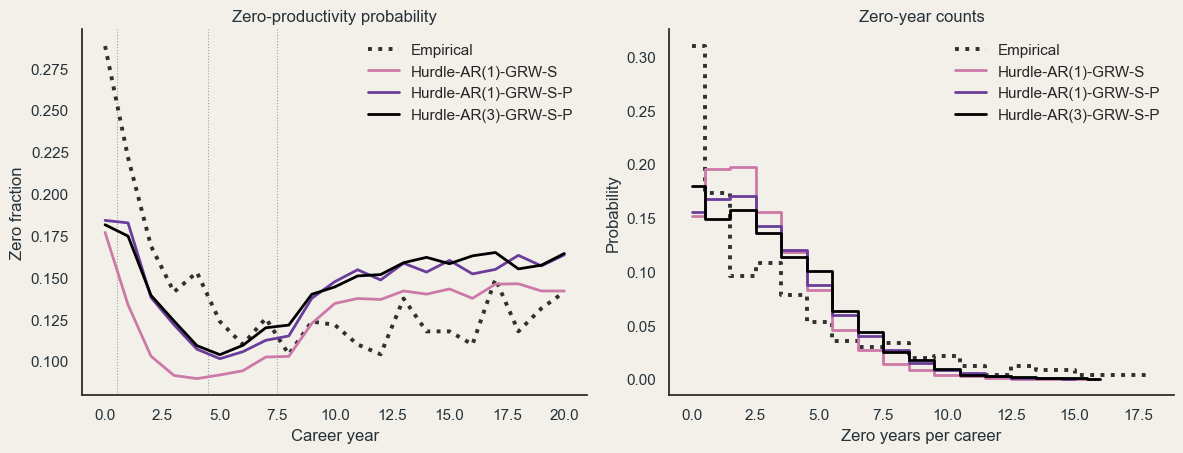

In [4]:
rows = []
for year in range(Y + 1):
    rows.append({"source": "Empirical", "model_tag": "empirical", "year": year, "zero_fraction": np.mean(emp_panel[year] == 0)})
    rows += [{"source": MODEL_NAMES[tag], "model_tag": tag, "year": year, "zero_fraction": np.mean(np.asarray(trajs[tag][year]) == 0)} for tag in HURDLE_MODELS]
zero_by_year = pd.DataFrame(rows)
zero_by_year.to_csv(RESULTS / "hurdle-zero-fraction-by-year.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
fig.patch.set_facecolor(PAPER_BG)
style_axis(axes[0], stages=True)
for tag in ["empirical"] + HURDLE_MODELS:
    frame = zero_by_year.loc[zero_by_year["model_tag"].eq(tag)]
    color = EMP_COLOR if tag == "empirical" else MODEL_COLORS[tag]
    axes[0].plot(frame["year"], frame["zero_fraction"], color=color, lw=2.8 if tag == "empirical" else 2, ls=":" if tag == "empirical" else "-", label=frame["source"].iloc[0])
axes[0].set(xlabel="Career year", ylabel="Zero fraction", title="Zero-productivity probability")
axes[0].legend(frameon=False)

count_rows = []
for tag, states in {"empirical": emp_active, **active}.items():
    counts = np.sum(~np.asarray(states), axis=0)
    pmf = pd.Series(counts).value_counts(normalize=True).sort_index()
    source = "Empirical" if tag == "empirical" else MODEL_NAMES[tag]
    count_rows += [{"source": source, "model_tag": tag, "zero_years": int(k), "probability": v} for k, v in pmf.items()]
zero_counts = pd.DataFrame(count_rows)
zero_counts.to_csv(RESULTS / "hurdle-zero-year-counts.csv", index=False)
style_axis(axes[1])
for tag in ["empirical"] + HURDLE_MODELS:
    frame = zero_counts.loc[zero_counts["model_tag"].eq(tag)]
    color = EMP_COLOR if tag == "empirical" else MODEL_COLORS[tag]
    axes[1].step(frame["zero_years"], frame["probability"], where="mid", color=color, lw=2.8 if tag == "empirical" else 2, ls=":" if tag == "empirical" else "-", label=frame["source"].iloc[0])
axes[1].set(xlabel="Zero years per career", ylabel="Probability", title="Zero-year counts")
axes[1].legend(frameon=False)
fig.tight_layout()
savefig(fig, "hurdle_zero_diagnostics.png")
plt.show()

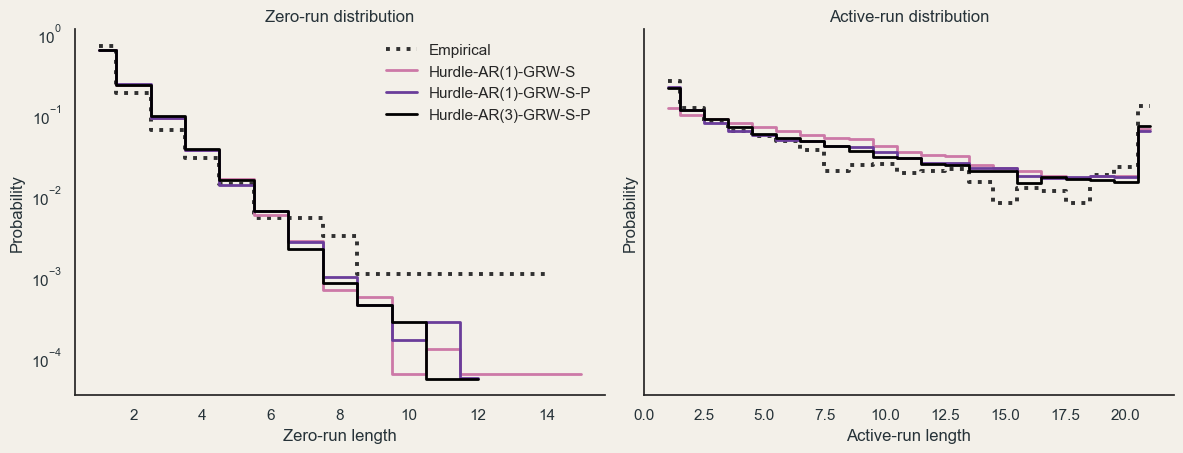

In [5]:
run_rows = []
for tag, states in {"empirical": emp_active, **active}.items():
    source = "Empirical" if tag == "empirical" else MODEL_NAMES[tag]
    for state_name, target in [("zero", False), ("active", True)]:
        pmf = pd.Series(extract_runs(states, target)).value_counts(normalize=True).sort_index()
        run_rows += [{"source": source, "model_tag": tag, "state": state_name, "run_length": int(k), "probability": v} for k, v in pmf.items()]
run_summary = pd.DataFrame(run_rows)
run_summary.to_csv(RESULTS / "hurdle-run-lengths.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharey=True)
fig.patch.set_facecolor(PAPER_BG)
for ax, state in zip(axes, ["zero", "active"]):
    style_axis(ax)
    for tag in ["empirical"] + HURDLE_MODELS:
        frame = run_summary.loc[run_summary["model_tag"].eq(tag) & run_summary["state"].eq(state)]
        color = EMP_COLOR if tag == "empirical" else MODEL_COLORS[tag]
        ax.step(frame["run_length"], frame["probability"], where="mid", color=color, lw=2.8 if tag == "empirical" else 2, ls=":" if tag == "empirical" else "-", label=frame["source"].iloc[0])
    ax.set_yscale("log")
    ax.set(xlabel=f"{state.title()}-run length", ylabel="Probability", title=f"{state.title()}-run distribution")
axes[0].legend(frameon=False)
fig.tight_layout()
savefig(fig, "hurdle_run_lengths.png")
plt.show()

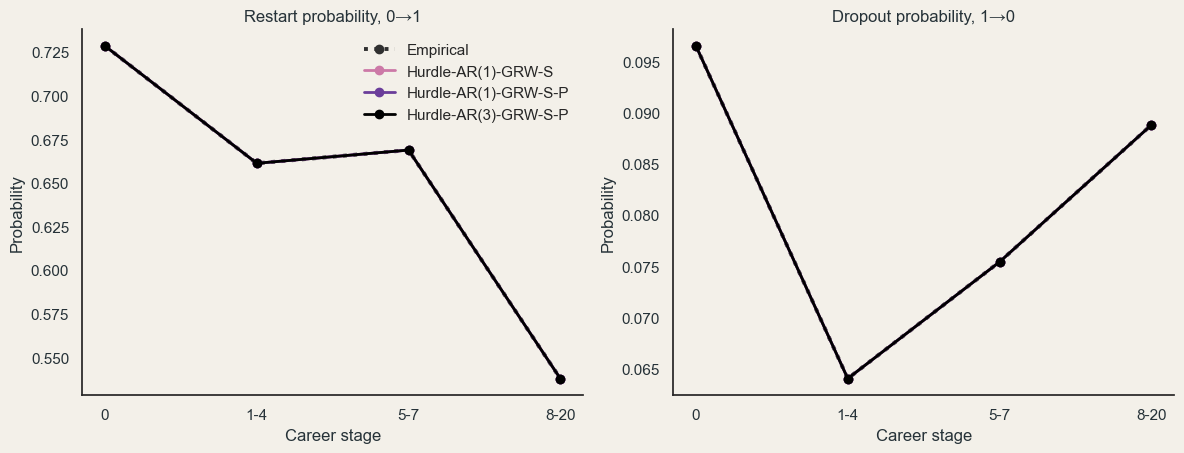

In [6]:
frames = [empirical_stage_transitions()]
for tag in HURDLE_MODELS:
    frame = read_parameter(tag, "stagewise-hurdle-parameters.csv")
    frame["source"] = MODEL_NAMES[tag]
    frame["model_tag"] = tag
    frames.append(frame)
transition_summary = pd.concat(frames, ignore_index=True)
transition_summary["stage"] = pd.Categorical(transition_summary["stage"], categories=STAGE_ORDER, ordered=True)
transition_summary.to_csv(RESULTS / "hurdle-stagewise-transition-probabilities.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharex=True)
fig.patch.set_facecolor(PAPER_BG)
for ax, column, title in [(axes[0], "p_01", "Restart probability, 0→1"), (axes[1], "p_10", "Dropout probability, 1→0")]:
    style_axis(ax)
    for tag in ["empirical"] + HURDLE_MODELS:
        frame = transition_summary.loc[transition_summary["model_tag"].eq(tag)].sort_values("stage")
        color = EMP_COLOR if tag == "empirical" else MODEL_COLORS[tag]
        ax.plot(frame["stage"].astype(str), frame[column], color=color, lw=2.8 if tag == "empirical" else 2, marker="o", ls=":" if tag == "empirical" else "-", label=frame["source"].iloc[0])
    ax.set(xlabel="Career stage", ylabel="Probability", title=title)
axes[0].legend(frameon=False)
fig.tight_layout()
savefig(fig, "hurdle_stagewise_transitions.png")
plt.show()

KeyError: 'dropout_gamma_positive'

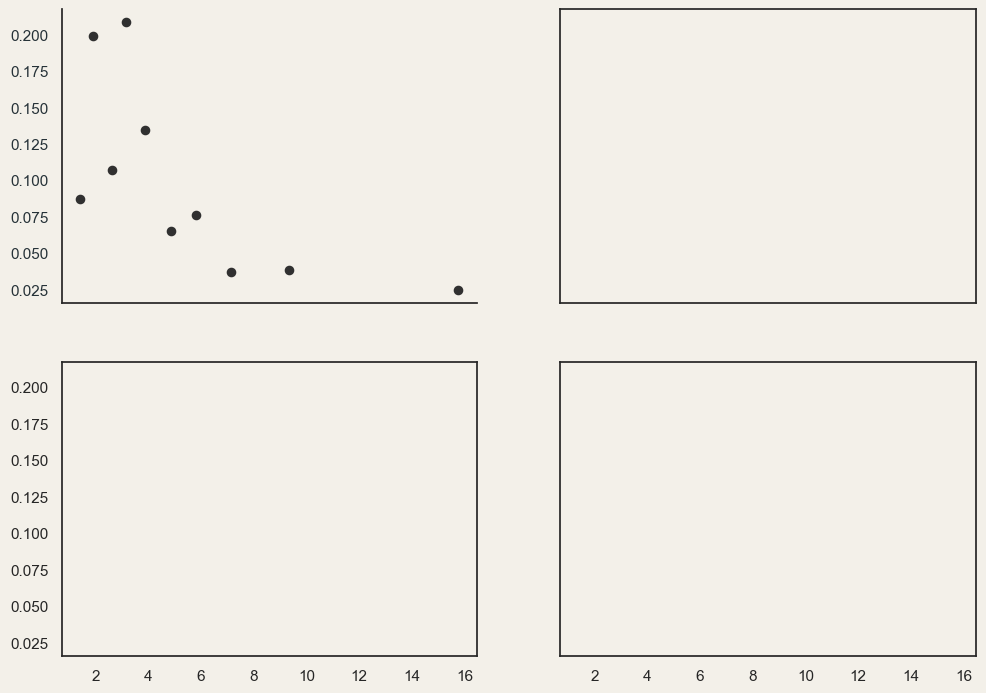

In [7]:
dropout_emp = emp_fit.loc[emp_fit["state"].eq(1)].copy()
dropout_emp["stage"] = dropout_emp["CareerAge"].map(stage_label)
dropout_emp["dropped"] = dropout_emp["next_state"].eq(0).astype(int)
fig, axes = plt.subplots(2, 2, figsize=(11.8, 8.4), sharex=True, sharey=True)
fig.patch.set_facecolor(PAPER_BG)
curve_rows = []
for ax, stage in zip(axes.flat, STAGE_ORDER):
    style_axis(ax)
    stage_emp = dropout_emp.loc[dropout_emp["stage"].eq(stage)].copy()
    q = min(10, stage_emp["pubs_adj"].nunique())
    if q >= 2:
        stage_emp["bin"] = pd.qcut(stage_emp["pubs_adj"], q=q, duplicates="drop")
        binned = stage_emp.groupby("bin", observed=True).agg(productivity=("pubs_adj", "mean"), dropout=("dropped", "mean"), n=("dropped", "size")).reset_index()
        ax.scatter(binned["productivity"], binned["dropout"], color=EMP_COLOR, s=35, label="Empirical bins")
        curve_rows += [{"source": "Empirical", "model_tag": "empirical", "stage": stage, **row} for row in binned[["productivity", "dropout", "n"]].to_dict("records")]
    for tag in [t for t in HURDLE_MODELS if (SIMULATE / t / "parameters" / "dropout-parameters.csv").is_file()]:
        row = read_parameter(tag, "dropout-parameters.csv").loc[lambda d: d["stage"].eq(stage)].iloc[0]
        grid = np.linspace(0, max(20, stage_emp["pubs_adj"].quantile(0.99)), 300)
        prob = 1 / (1 + np.exp(-(row["dropout_intercept"] + row["dropout_gamma_positive"] * grid / row["productivity_scale"])))
        ax.plot(grid, prob, color=MODEL_COLORS[tag], lw=2, label=MODEL_NAMES[tag])
        curve_rows += [{"source": MODEL_NAMES[tag], "model_tag": tag, "stage": stage, "productivity": x, "dropout": p, "n": np.nan} for x, p in zip(grid, prob)]
    ax.set(xlabel="Current productivity", ylabel="P(drop to zero)", title=f"Stage {stage}")
axes[0, 0].legend(frameon=False)
fig.tight_layout()
savefig(fig, "hurdle_productivity_dependent_dropout.png")
plt.show()
pd.DataFrame(curve_rows).to_csv(RESULTS / "hurdle-dropout-curves.csv", index=False)

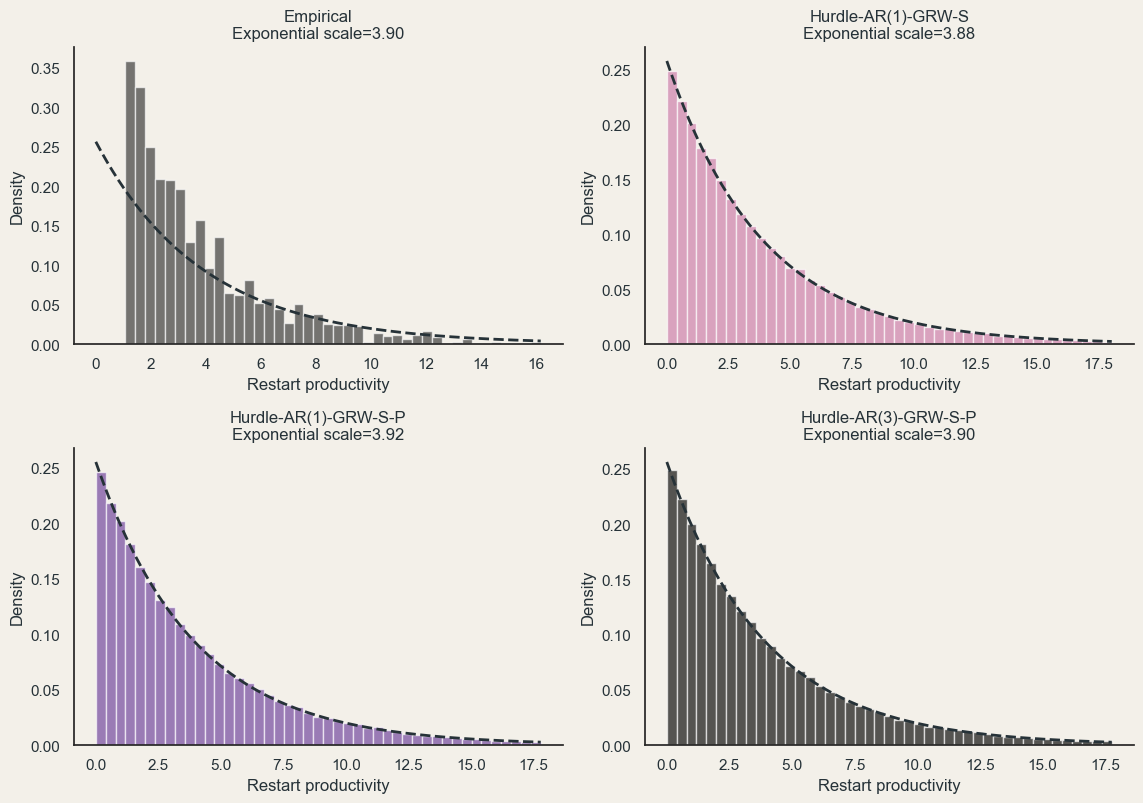

In [ ]:
restart_sources = {"empirical": emp_fit.loc[emp_fit["state"].eq(0) & emp_fit["next_state"].eq(1), "pubs_adj_next_model"].to_numpy(dtype=float)}
for tag in HURDLE_MODELS:
    states, values = np.asarray(active[tag]), np.asarray(trajs[tag])
    restart_sources[tag] = values[1:][(~states[:-1]) & states[1:]]
fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.2))
fig.patch.set_facecolor(PAPER_BG)
restart_rows = []
for ax, tag in zip(axes.flat, ["empirical"] + HURDLE_MODELS):
    style_axis(ax)
    values = restart_sources[tag]
    values = values[np.isfinite(values) & (values > 0)]
    scale = values.mean()
    xmax = np.quantile(values, 0.99)
    grid = np.linspace(0, xmax, 400)
    color = EMP_COLOR if tag == "empirical" else MODEL_COLORS[tag]
    name = "Empirical" if tag == "empirical" else MODEL_NAMES[tag]
    ax.hist(values, bins=45, range=(0, xmax), density=True, color=color, alpha=0.65)
    ax.plot(grid, stats.expon.pdf(grid, scale=scale), color=INK, lw=2, ls="--")
    ax.set(xlabel="Restart productivity", ylabel="Density", title=f"{name}\nExponential scale={scale:.2f}")
    restart_rows.append({"source": name, "model_tag": tag, "n": len(values), "exponential_scale": scale})
fig.tight_layout()
savefig(fig, "hurdle_restart_magnitudes.png")
plt.show()
pd.DataFrame(restart_rows).to_csv(RESULTS / "hurdle-restart-summary.csv", index=False)